Import the necessary libraries for data manipulation and visualization.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


# script A-01 - Retail - Import Merge Data

Data directory

In [2]:
data_dir = Path("Data")

ZIP COUNTY MAPPING

In [3]:
zip_df = pd.read_excel(
    data_dir / "HUD/ZIP_COUNTY_122024.xlsx",
    sheet_name="Export Worksheet",
    dtype=str,
    keep_default_na=False,
)
zip_df = zip_df[zip_df["USPS_ZIP_PREF_STATE"] == "CA"]
zip_df = zip_df[~zip_df.duplicated(subset=["ZIP"], keep=False)]
zip_df = zip_df[["ZIP", "retailercounty"]].rename(columns={"ZIP": "zip5"})

PARENT COMPANY

In [4]:
parent_df = pd.read_csv(
    data_dir
    / "Cannabiz/Cannabis Market Intelligence Platform Report - Licenses - 2025-02-21.csv",
    dtype=str,
    keep_default_na=False,
)
parent_df = parent_df.rename(
    columns={
        "Company ID": "companyid",
        "Country": "county",
        "State License ID": "statelicenseid",
    }
)
parent_df["multi_owner"] = 0
parent_df["multi_owner"] = parent_df["companyid"].str.find(";")

parent_df["multi_owner"] = parent_df["multi_owner"].replace(-1, 0)
parent_df["primary_company"] = parent_df.apply(
    lambda row: row["companyid"][: row["multi_owner"]]
    if row["multi_owner"] > 0
    else row["companyid"],
    axis=1,
)

parent_df["primary_company"] = pd.to_numeric(
    parent_df["primary_company"], errors="coerce"
)

parent_df = parent_df[["statelicenseid", "primary_company", "county"]]
parent_df = parent_df.rename(
    columns={"statelicenseid": "retailerlicensenumber", "county": "cannabiz_county"}
)
parent_df = parent_df.drop_duplicates()
parent_df = parent_df[
    parent_df["retailerlicensenumber"].notna()
    & (parent_df["retailerlicensenumber"] != "")
]
parent_temp = parent_df.copy()

SALES FILES

In [5]:
sales_files = [
    "sales18.csv",
    "sales19.csv",
    "sales20.csv",
    "sales21.csv",
    "sales22.csv",
    "sales23v2.csv",
    "sales24.csv",
]
sales_dir = data_dir / "Track and Trace Data" / "Retail"

processed_sales = {}

for file in sales_files:
    df = pd.read_csv(sales_dir / file, dtype=str, keep_default_na=False)
    df = df.drop(columns=[c for c in ["meanprice", "v1"] if c in df.columns])
    year_key = file.replace(".csv", "")
    processed_sales[year_key] = df.copy()

sales_df = processed_sales["sales18"]
for year_key in ["sales19", "sales20", "sales21", "sales22", "sales23v2", "sales24"]:
    sales_df = pd.concat([sales_df, processed_sales[year_key]], ignore_index=True)


sales_df.rename(columns={"ItemCategory": "itemcategory"}, inplace=True)

sales_df["itemcategory"].value_counts(dropna=False)

itemcategory
Edible (weight - each)                 68158
Pre-Roll Flower                        67669
Extract (weight - each)                66743
Pre-Roll Infused                       65934
Flower (packaged eighth - each)        65243
Other Concentrate (weight - each)      64625
Vape Cartridge (weight - each)         64387
Tincture (volume - each)               61285
Vape Cartridge (volume - each)         60413
Edible (volume - each)                 58704
Flower (packaged half ounce - each)    56335
Topical (volume - each)                53152
Flower (packaged quarter - each)       52259
Capsule (weight - each)                51752
Topical (weight - each)                51185
Flower (packaged - each)               50923
Pre-Roll Leaf                          50775
Flower (packaged gram - each)          50431
Flower (packaged ounce - each)         47248
Tincture (weight - each)               26331
Other Concentrate (volume - each)      18276
Extract (volume - each)                180

Data Cleaning and County Mapping for Sales Data Merge

In [6]:
working_dir = data_dir / "Working_data"


sales_df = sales_df.rename(
    columns={
        "RetailerLicenseNumber": "retailerlicensenumber",
        "RetailerCounty": "retailercounty",
        "RetailerFacilityType": "retailerfacilitytype",
        "RetailerCity": "retailercity",
        "RetailerZipCode": "retailerzipcode",
        "Date": "date",
        "ItemCategory": "itemcategory",
        "totalsales": "totalsales",
    }
)

sales_df = sales_df.sort_values(
    by=[
        "retailerlicensenumber",
        "retailercounty",
        "retailerfacilitytype",
        "retailercity",
        "retailerzipcode",
        "date",
        "itemcategory",
        "totalsales",
    ],
    ascending=[True, False, True, True, True, True, True, True],
)

df = sales_df.merge(parent_temp, on="retailerlicensenumber", how="left", indicator=True)
df = df[df["_merge"] != "right_only"]
df = df.drop(columns="_merge")

df["retailercounty"] = df["retailercounty"].replace({"NA": "", "UNDEFINED": ""})

county_map = {
    "Alameda County": "ALAMEDA",
    "El Dorado County": "EL DORADO",
    "Humboldt County": "HUMBOLDT",
    "Imperial County": "IMPERIAL",
    "Inyo County": "INYO",
    "Kern County": "KERN",
    "Kings County": "KINGS",
    "Los Angeles County": "LOS ANGELES",
    "Marin County": "MARIN",
    "Mendocino County": "MENDOCINO",
    "Merced County": "MERCED",
    "Monterey County": "MONTEREY",
    "Nevada County": "NEVADA",
    "Riverside County": "RIVERSIDE",
    "Sacramento County": "SACRAMENTO",
    "San Diego County": "SAN DIEGO",
    "San Francisco County": "SAN FRANCISCO",
    "San Luis Obispo County": "SAN LUIS OBISPO",
    "San Mateo County": "SAN MATEO",
    "Santa Barbara County": "SANTA BARBARA",
    "Santa Cruz County": "SANTA CRUZ",
    "Shasta County": "SHASTA",
    "Sonoma County": "SONOMA",
    "Stanislaus County": "STANISLAUS",
    "Tulare County": "TULARE",
    "Ventura County": "VENTURA",
    "Calaveras County": "CALAVERAS",
    "Lassen County": "LASSEN",
    "Mono County": "MONO",
    "Napa County": "NAPA",
    "San Benito County": "SAN BENITO",
    "San Bernardino County": "SAN BERNARDINO",
    "San Joaquin County": "SAN JOAQUIN",
    "Santa Clara County": "SANTA CLARA",
    "Yuba County": "YUBA",
}

for cannabiz_val, county_val in county_map.items():
    mask = (df["cannabiz_county"] == cannabiz_val) & (df["retailercounty"] == "")
    df.loc[mask, "retailercounty"] = county_val

manual_county_fix = {
    "C10-0000209-LIC": "RIVERSIDE",
    "C12-0000370-LIC": "SAN BERNARDINO",
}
for lic, county in manual_county_fix.items():
    df.loc[df["retailerlicensenumber"] == lic, "retailercounty"] = county

df["retailercounty"] = df["retailercounty"].str.upper()

license_county = df.loc[
    (df["retailerlicensenumber"] != "") & (df["retailercounty"] != ""),
    ["retailerlicensenumber", "retailercounty"],
].drop_duplicates()

df = df.merge(
    license_county,
    on="retailerlicensenumber",
    how="left",
    suffixes=("", "_from_license_county"),
)

merge_code = pd.Series(1, index=df.index)
merge_code[df["retailercounty_from_license_county"].notna()] = 3

mask_update = (df["retailercounty"] == "") & df[
    "retailercounty_from_license_county"
].notna()
merge_code[mask_update] = 4

df.loc[mask_update, "retailercounty"] = df.loc[
    mask_update, "retailercounty_from_license_county"
]

df["_merge_lic_county"] = merge_code
labels = {1: "Master only", 3: "Matched", 4: "Matched & updated"}
df["_merge_lic_county"] = df["_merge_lic_county"].map(labels)
df = df.drop(columns=["retailercounty_from_license_county"])

Zip Code Merge & Manual County Fixes in Sales Data

In [7]:
df["zip5"] = df["retailerzipcode"].astype(str).str[:5]

df = df.merge(zip_df, on="zip5", how="left", suffixes=("", "_from_zip"))

merge_zip_code = pd.Series(1, index=df.index)
merge_zip_code[df["retailercounty_from_zip"].notna()] = 3

mask_update_zip = (df["retailercounty"] == "") & df["retailercounty_from_zip"].notna()
merge_zip_code[mask_update_zip] = 4

df.loc[mask_update_zip, "retailercounty"] = df.loc[
    mask_update_zip, "retailercounty_from_zip"
]
df["_merge_zip"] = merge_zip_code
df = df[df["_merge_zip"] != 2]


labels = {1: "Master only", 3: "Matched", 4: "Matched & updated"}
df["_merge_zip"] = df["_merge_zip"].map(labels)
df = df.drop(columns=["retailercounty_from_zip"])
df = df.drop(columns=["_merge_zip"])
df = df.drop(columns=["Unnamed: 0"])

more_manual_fixes = {
    "C10-0000279-LIC": "LOS ANGELES",
    "C10-0000747-LIC": "LOS ANGELES",
    "C12-0000056-LIC": "LOS ANGELES",
    "C9-0000499-LIC": "LOS ANGELES",
    "C10-0000248-LIC": "LOS ANGELES",
    "C9-0000386-LIC": "KINGS",
    "C10-0000343-LIC": "TULARE",
    "C10-0000299-LIC": "TULARE",
    "C10-0000078-LIC": "MONO",
    "C10-0000265-LIC": "SAN FRANCISCO",
    "C12-0000068-LIC": "SOLANO",
    "C9-0000396-LIC": "SAN BENITO",
    "C10-0000238-LIC": "SANTA CRUZ",
    "C10-0000576-LIC": "STANISLAUS",
    "C10-0000022-LIC": "STANISLAUS",
    "C12-0000157-LIC": "SACRAMENTO",
    "C10-0000190-LIC": "HUMBOLDT",
    "C10-0000148-LIC": "YOLO",
    "C10-0000111-LIC": "YOLO",
    "C9-0000088-LIC": "YOLO",
    "C10-0000449-LIC": "YUBA",
    "C10-0000707-LIC": "YUBA",
    "C10-0000398-LIC": "LOS ANGELES",
    "C10-0000382-LIC": "MONO",
    "C10-0000200-LIC": "SAN FRANCISCO",
    "C10-0000152-LIC": "SAN FRANCISCO",
    "C9-0000376-LIC": "SOLANO",
    "C10-0000098-LIC": "LOS ANGELES",
    "C10-0000196-LIC": "STANISLAUS",
    "C9-0000142-LIC": "YOLO",
    "C9-0000061-LIC": "NEVADA",
}
for lic, county in more_manual_fixes.items():
    df.loc[df["retailerlicensenumber"] == lic, "retailercounty"] = county

df = df.fillna("").astype(str)
df["retailercounty"].value_counts(dropna=False)

output_path = working_dir / "sales_w_parent_co_test.dta"
df.to_stata(output_path, write_index=False)

# A-02 - Retail - Calculate_Concentration

Read the exported data

In [8]:
df = pd.read_stata(
    working_dir / "sales_w_parent_co_test.dta", convert_categoricals=False
)

In [ ]:
df

Date Parsing and Data Type Standardization

In [9]:
df["year"] = df["date"].astype(str).str[3:7]
df["totalsales"] = pd.to_numeric(df["totalsales"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

Statewide HHI overall (CA_overall)

In [10]:
collapsed = df.groupby(["retailerlicensenumber", "year"], as_index=False).agg(
    {"totalsales": "sum", "retailerzipcode": "first", "primary_company": "first"}
)

collapsed["industry_sales"] = collapsed.groupby("year")["totalsales"].transform("sum")
collapsed["mkt_share"] = (collapsed["totalsales"] / collapsed["industry_sales"]) * 100
collapsed["mkt_share2"] = collapsed["mkt_share"] ** 2

CA_overall = collapsed.groupby("year", as_index=False).agg(
    {"mkt_share2": "sum", "totalsales": "sum"}
)
CA_overall["retailercounty"] = "CA"

Statewide HHI by parent company (CA_parent)

In [11]:
df_parent = df.copy()
df_parent["primary_company"] = df_parent["primary_company"].where(
    df_parent["primary_company"].astype(str).str.strip() != "",
    df_parent["retailerlicensenumber"],
)

collapsed_parent = df_parent.groupby(["primary_company", "year"], as_index=False).agg(
    {"totalsales": "sum", "retailerzipcode": "first"}
)

collapsed_parent["industry_sales"] = collapsed_parent.groupby("year")[
    "totalsales"
].transform("sum")
collapsed_parent["mkt_share"] = (
    collapsed_parent["totalsales"] / collapsed_parent["industry_sales"]
) * 100
collapsed_parent["mkt_share2"] = collapsed_parent["mkt_share"] ** 2

CA_parent = collapsed_parent.groupby("year", as_index=False).agg(
    {"mkt_share2": "sum", "totalsales": "sum"}
)
CA_parent = CA_parent.rename(
    columns={"mkt_share2": "mkt_share2_parent", "totalsales": "totalsales_parent"}
)
CA_parent["retailercounty"] = "CA"

County-level HHI overall (county_overall)

In [12]:
collapsed_county = df.groupby(
    ["retailerlicensenumber", "retailercounty", "year"], as_index=False
).agg({"totalsales": "sum", "retailerzipcode": "first", "primary_company": "first"})
collapsed_county["industry_sales"] = collapsed_county.groupby(
    ["retailercounty", "year"]
)["totalsales"].transform("sum")
collapsed_county["mkt_share"] = (
    collapsed_county["totalsales"] / collapsed_county["industry_sales"]
) * 100
collapsed_county["mkt_share2"] = collapsed_county["mkt_share"] ** 2

county_overall = collapsed_county.groupby(
    ["retailercounty", "year"], as_index=False
).agg({"mkt_share2": "sum", "totalsales": "sum"})

County-level HHI by parent company (county_parent)

In [13]:
df_parent_county = df.copy()
df_parent_county["primary_company"] = df_parent_county["primary_company"].where(
    df_parent_county["primary_company"].astype(str).str.strip() != "",
    df_parent_county["retailerlicensenumber"],
)

collapsed_county_parent = df_parent_county.groupby(
    ["primary_company", "retailercounty", "year"], as_index=False
).agg({"totalsales": "sum", "retailerzipcode": "first"})
collapsed_county_parent["industry_sales"] = collapsed_county_parent.groupby(
    ["retailercounty", "year"]
)["totalsales"].transform("sum")
collapsed_county_parent["mkt_share"] = (
    collapsed_county_parent["totalsales"] / collapsed_county_parent["industry_sales"]
) * 100
collapsed_county_parent["mkt_share2"] = collapsed_county_parent["mkt_share"] ** 2

county_parent = collapsed_county_parent.groupby(
    ["retailercounty", "year"], as_index=False
).agg({"mkt_share2": "sum", "totalsales": "sum"})
county_parent = county_parent.rename(
    columns={"mkt_share2": "mkt_share2_parent", "totalsales": "totalsales_parent"}
)

Merge all results like Stata's append + merge sequence

In [14]:
all_overall = pd.concat([county_overall, CA_overall], ignore_index=True)
merged = pd.merge(all_overall, county_parent, on=["retailercounty", "year"], how="left")
merged = pd.merge(
    merged, CA_parent, on=["retailercounty", "year"], how="left", suffixes=("", "_ca")
)
for col in ["mkt_share2_parent", "totalsales_parent"]:
    merged[col] = merged[col].combine_first(merged[f"{col}_ca"])
    merged.drop(columns=[f"{col}_ca"], inplace=True)

Final calculations (opacity)

In [15]:
max_sales = merged.loc[merged["retailercounty"] == "CA", "totalsales"].sum()
max_sales2 = max_sales

merged["county_sales"] = merged.groupby("retailercounty")["totalsales"].transform("sum")
merged["county_sales_parent"] = merged.groupby("retailercounty")[
    "totalsales_parent"
].transform("sum")

merged["opacity"] = round((merged["county_sales"] / max_sales2) * 100)
merged["opacity_parent"] = round((merged["county_sales_parent"] / max_sales2) * 100)

In [ ]:
merged

HHI Over Time by County

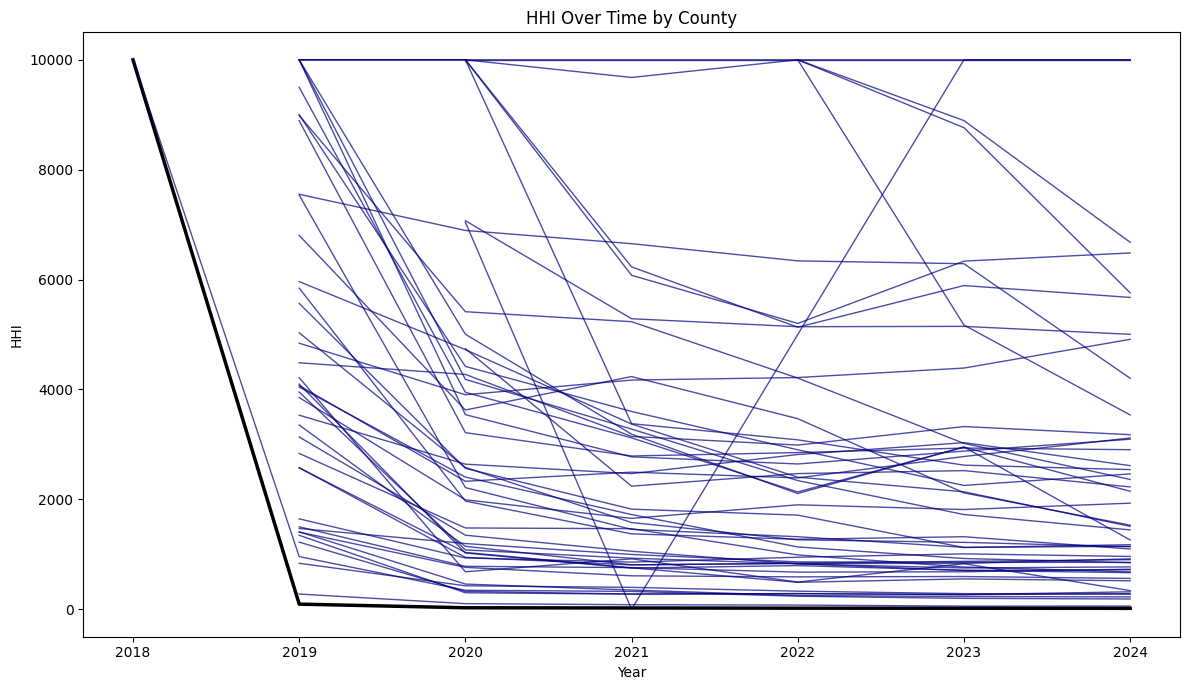

In [16]:
plot_df = merged.copy()

counties = plot_df["retailercounty"].unique()

fig, ax = plt.subplots(figsize=(12, 7))

for county in sorted(counties):
    county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
    if county == "CA":
        ax.plot(
            county_data["year"],
            county_data["mkt_share2"],
            color="black",
            linewidth=2.5,
            label="CA",
        )
    else:
        ax.plot(
            county_data["year"],
            county_data["mkt_share2"],
            color="navy",
            linewidth=1,
            alpha=0.7,
        )

ax.set_xlabel("Year")
ax.set_ylabel("HHI")
ax.set_title("HHI Over Time by County")

ax.set_xticks(range(2018, 2025))
ax.set_xticklabels(range(2018, 2025))

ax.tick_params(axis="y", rotation=0)

ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

In [33]:
# Keep only 2019–2025
filtered_df = plot_df[(plot_df["year"] >= 2019) & (plot_df["year"] <= 2025)]

# Pivot table
hhi_table = filtered_df.pivot_table(
    index="retailercounty",
    columns="year",
    values="mkt_share2",
    aggfunc="mean"
).reset_index()

# Save to CSV
hhi_table.to_csv("hhi_by_county.csv", index=False)

print("CSV file saved as hhi_by_county.csv (2019–2025)")


CSV file saved as hhi_by_county.csv (2019–2025)


HHI Over Time by County (Parent Company Level)

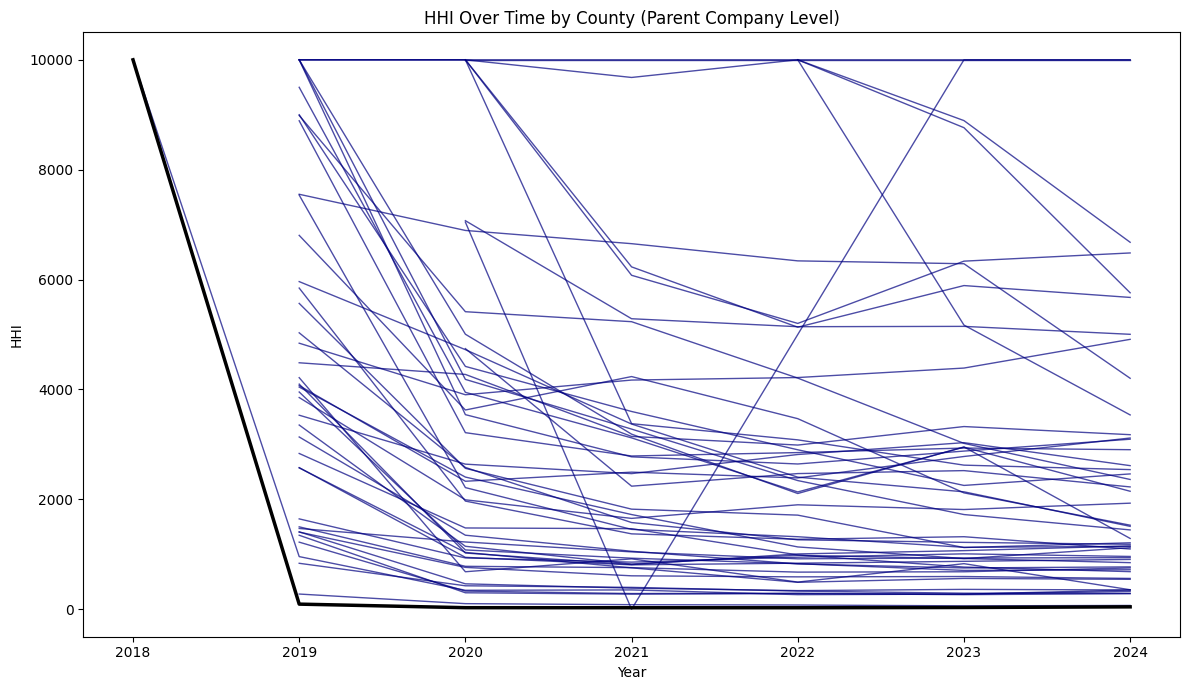

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

for county in counties:
    county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
    if county == "CA":
        ax.plot(
            county_data["year"],
            county_data["mkt_share2_parent"],
            color="black",
            linewidth=2.5,
            label="CA",
        )
    else:
        ax.plot(
            county_data["year"],
            county_data["mkt_share2_parent"],
            color="navy",
            linewidth=1,
            alpha=0.7,
        )

ax.set_xlabel("Year")
ax.set_ylabel("HHI")
ax.set_title("HHI Over Time by County (Parent Company Level)")

ax.set_xticks(range(2018, 2025))
ax.set_xticklabels(range(2018, 2025))

ax.tick_params(axis="y", rotation=0)

ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
# Filter 2019–2025 only
filtered_df = plot_df[(plot_df["year"] >= 2019) & (plot_df["year"] <= 2025)]

# Pivot table
hhi_parent_table = filtered_df.pivot_table(
    index="retailercounty",
    columns="year",
    values="mkt_share2_parent",
    aggfunc="mean"
).reset_index()

# Export to CSV
hhi_parent_table.to_csv("hhi_by_county_parent.csv", index=False)

print("CSV file saved as hhi_by_county_parent.csv (2019–2025)")


CSV file saved as hhi_by_county_parent.csv (2019–2025)


HHI Results Formatting and Export

In [20]:
final_export = merged.copy()
final_export = final_export.rename(
    columns={"mkt_share2": "HHI", "mkt_share2_parent": "HHI_parent_level"}
)
final_export["HHI"] = final_export["HHI"].round(0).astype(int)
final_export["HHI_parent_level"] = final_export["HHI_parent_level"].round(0).astype(int)
final_export = final_export[["retailercounty", "year", "HHI", "HHI_parent_level"]]
final_export = final_export.astype(str)
final_export.to_excel(data_dir / "Results/HHI_by_county_test.xlsx", index=False)

In [21]:

df_filtered = plot_df[plot_df['year'] != 2018]
display(df_filtered.head())

,retailercounty,year,mkt_share2,totalsales,mkt_share2_parent,totalsales_parent,county_sales,county_sales_parent,opacity,opacity_parent
0,ALAMEDA,2019,1221.438045,3.056429e+07,1221.438045,3.056429e+07,1.442727e+09,1.442727e+09,6.0,6.0
1,ALAMEDA,2020,325.301235,3.193678e+08,330.293936,3.193678e+08,1.442727e+09,1.442727e+09,6.0,6.0
2,ALAMEDA,2021,277.179756,3.494982e+08,285.976882,3.494982e+08,1.442727e+09,1.442727e+09,6.0,6.0
3,ALAMEDA,2022,285.219025,2.762145e+08,291.856447,2.762145e+08,1.442727e+09,1.442727e+09,6.0,6.0
4,ALAMEDA,2023,267.070185,2.529726e+08,275.638416,2.529726e+08,1.442727e+09,1.442727e+09,6.0,6.0


In [22]:
from sklearn.cluster import KMeans

df_pivot = df_filtered.pivot(index='retailercounty', columns='year', values='mkt_share2')
df_pivot = df_pivot.fillna(0)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pivot['cluster'] = kmeans.fit_predict(df_pivot)

df_filtered = pd.merge(df_filtered, df_pivot[['cluster']], on='retailercounty', how='left')
display(df_filtered.head())

,retailercounty,year,mkt_share2,totalsales,mkt_share2_parent,totalsales_parent,county_sales,county_sales_parent,opacity,opacity_parent,cluster
0,ALAMEDA,2019,1221.438045,3.056429e+07,1221.438045,3.056429e+07,1.442727e+09,1.442727e+09,6.0,6.0,0
1,ALAMEDA,2020,325.301235,3.193678e+08,330.293936,3.193678e+08,1.442727e+09,1.442727e+09,6.0,6.0,0
2,ALAMEDA,2021,277.179756,3.494982e+08,285.976882,3.494982e+08,1.442727e+09,1.442727e+09,6.0,6.0,0
3,ALAMEDA,2022,285.219025,2.762145e+08,291.856447,2.762145e+08,1.442727e+09,1.442727e+09,6.0,6.0,0
4,ALAMEDA,2023,267.070185,2.529726e+08,275.638416,2.529726e+08,1.442727e+09,1.442727e+09,6.0,6.0,0


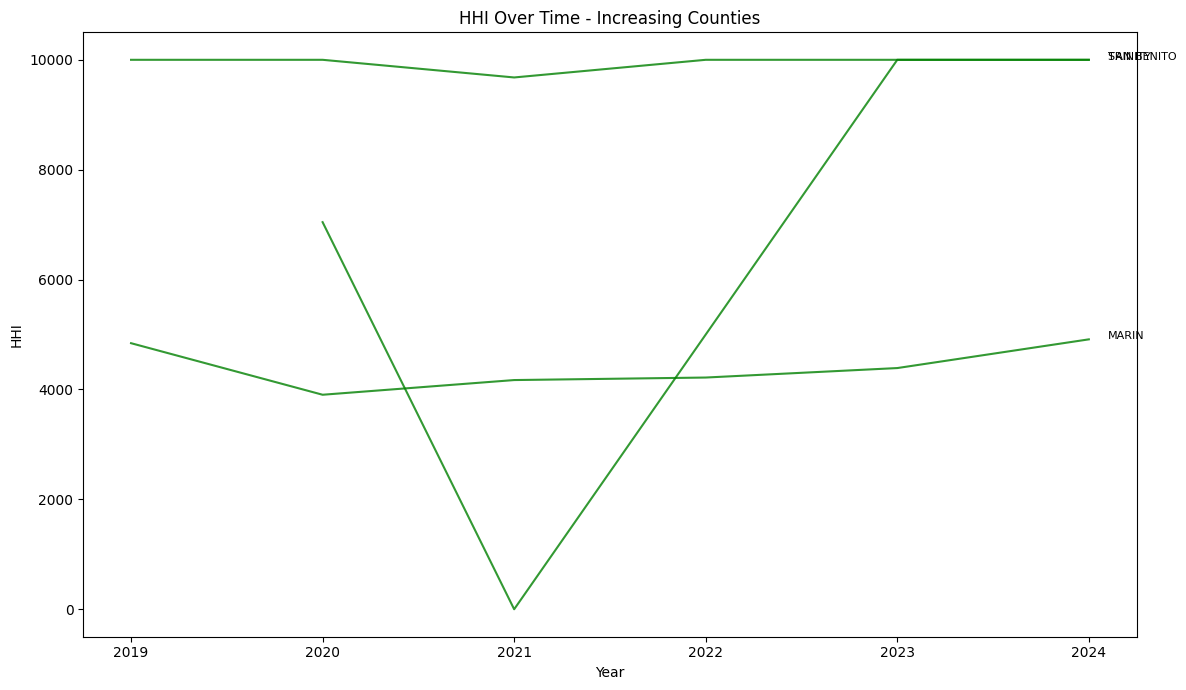

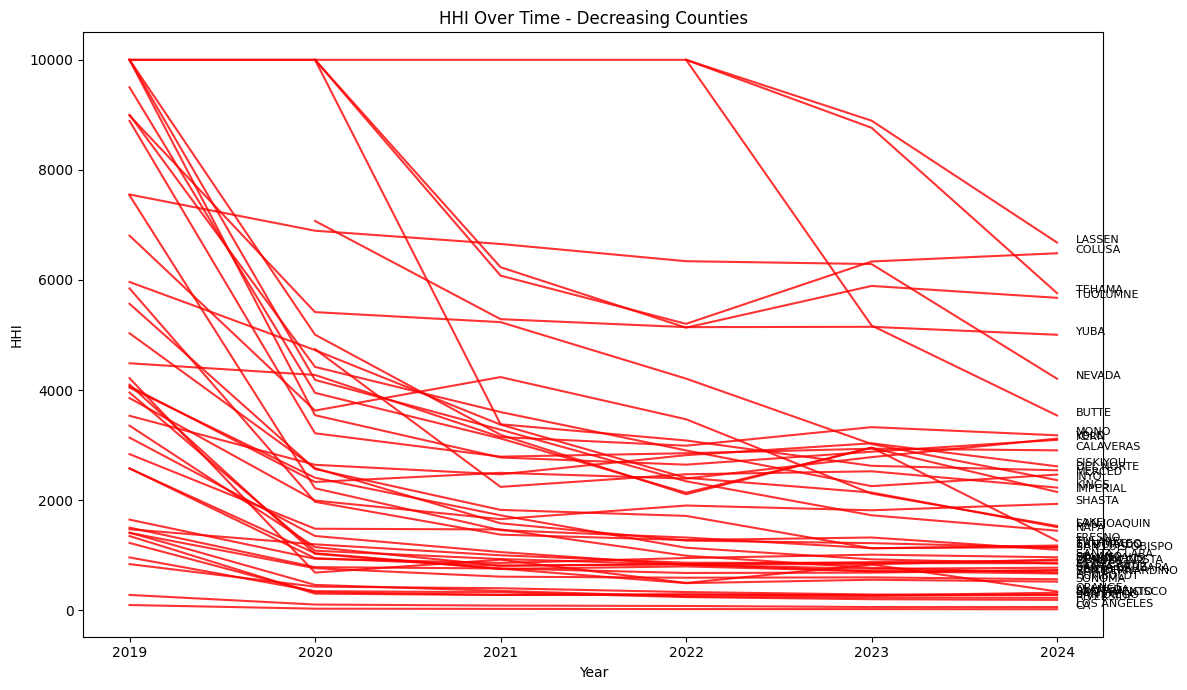

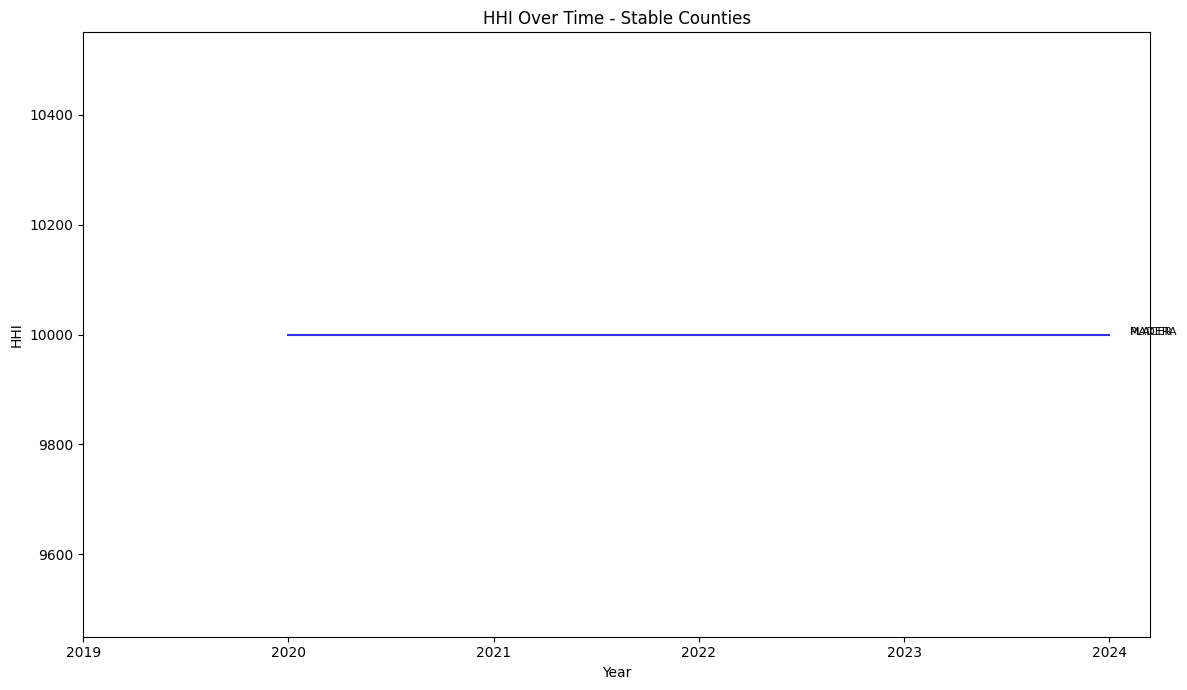

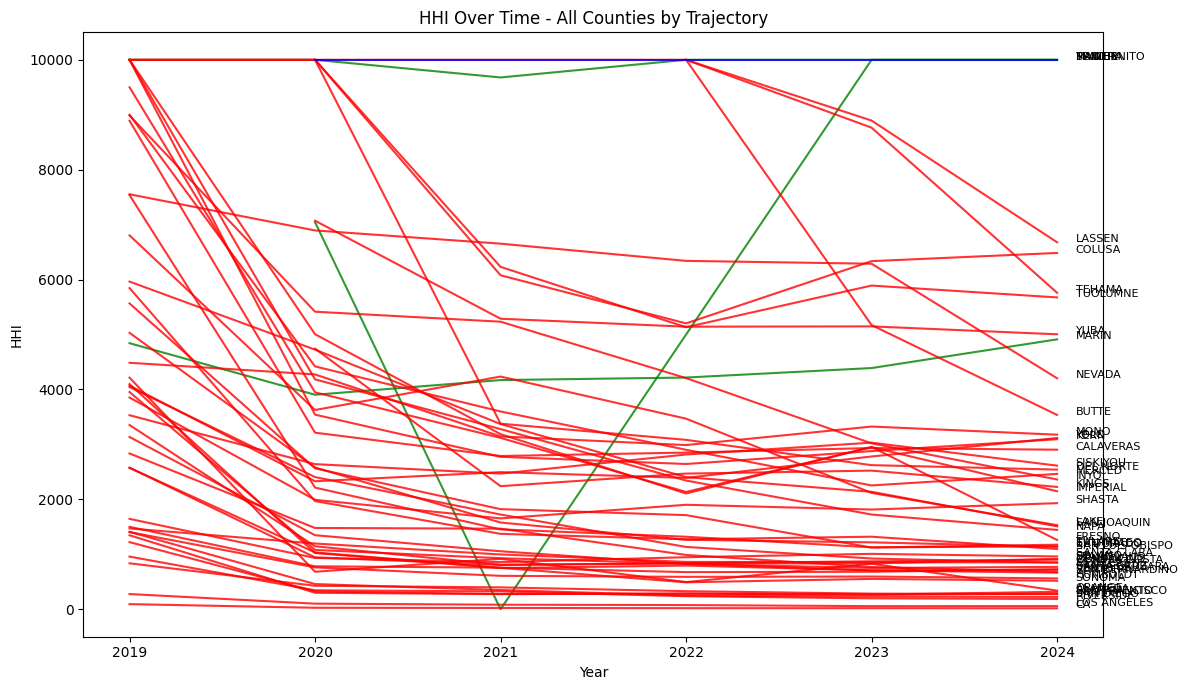

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

plot_df = merged.copy()

plot_df = plot_df[plot_df["year"] >= 2019]

counties = plot_df["retailercounty"].unique()

county_groups = {"increasing": [], "decreasing": [], "stable": []}
slopes = {}

for county in counties:
    county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
    
    X = county_data["year"].values.reshape(-1, 1)
    y = county_data["mkt_share2"].values
    model = LinearRegression().fit(X, y)
    slope = model.coef_[0]
    slopes[county] = slope
    
    if slope > 5:  
        county_groups["increasing"].append(county)
    elif slope < -5:
        county_groups["decreasing"].append(county)
    else:
        county_groups["stable"].append(county)

def plot_group(group_name, counties, color, title):
    fig, ax = plt.subplots(figsize=(12, 7))
    for county in counties:
        county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
        ax.plot(county_data["year"], county_data["mkt_share2"], label=county, color=color, alpha=0.8)
        ax.text(county_data["year"].iloc[-1] + 0.1,
                county_data["mkt_share2"].iloc[-1],
                county, fontsize=8)
    
    ax.set_xlabel("Year")
    ax.set_ylabel("HHI")
    ax.set_title(title)
    ax.set_xticks(range(2019, 2025))
    ax.set_xticklabels(range(2019, 2025))
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

plot_group("increasing", county_groups["increasing"], "green", "HHI Over Time - Increasing Counties")
plot_group("decreasing", county_groups["decreasing"], "red", "HHI Over Time - Decreasing Counties")
plot_group("stable", county_groups["stable"], "blue", "HHI Over Time - Stable Counties")

fig, ax = plt.subplots(figsize=(12, 7))
colors = {"increasing": "green", "decreasing": "red", "stable": "blue"}

for group, counties in county_groups.items():
    for county in counties:
        county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
        ax.plot(county_data["year"], county_data["mkt_share2"], 
                label=f"{county} ({group})", 
                color=colors[group], alpha=0.8)
        ax.text(county_data["year"].iloc[-1] + 0.1,
                county_data["mkt_share2"].iloc[-1],
                county, fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("HHI")
ax.set_title("HHI Over Time - All Counties by Trajectory")
ax.set_xticks(range(2019, 2025))
ax.set_xticklabels(range(2019, 2025))
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()


C:\Users\nooro\AppData\Local\Temp\ipykernel_56388\697922157.py:19: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(X, y, 1)


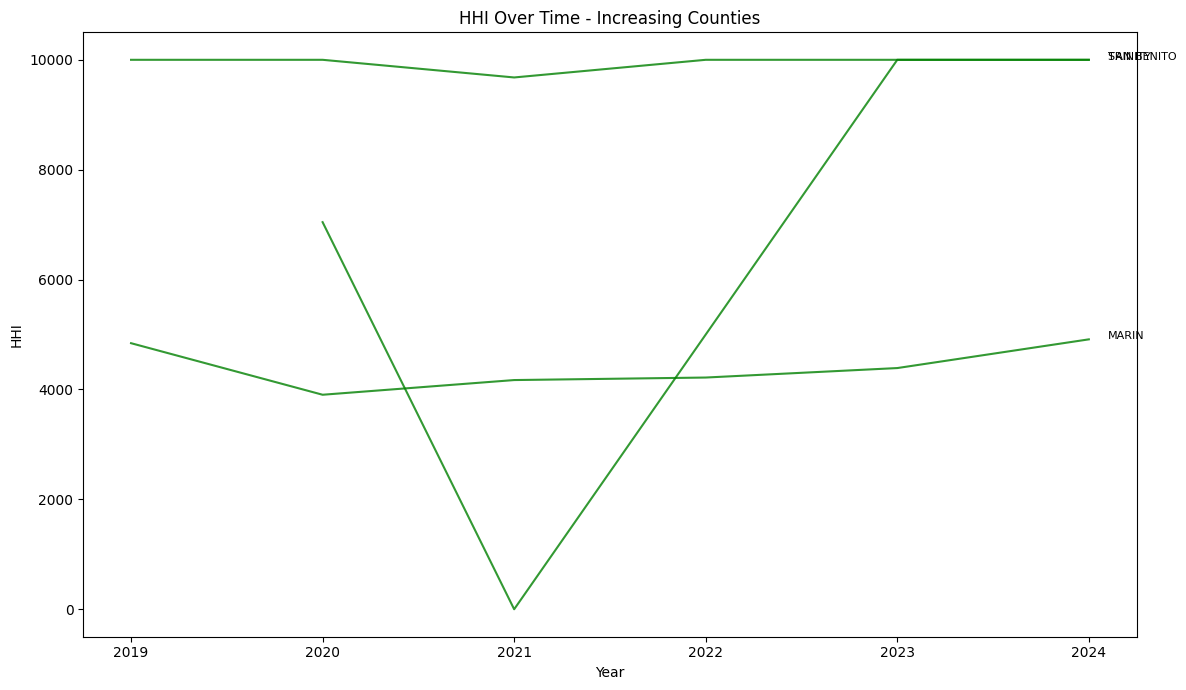

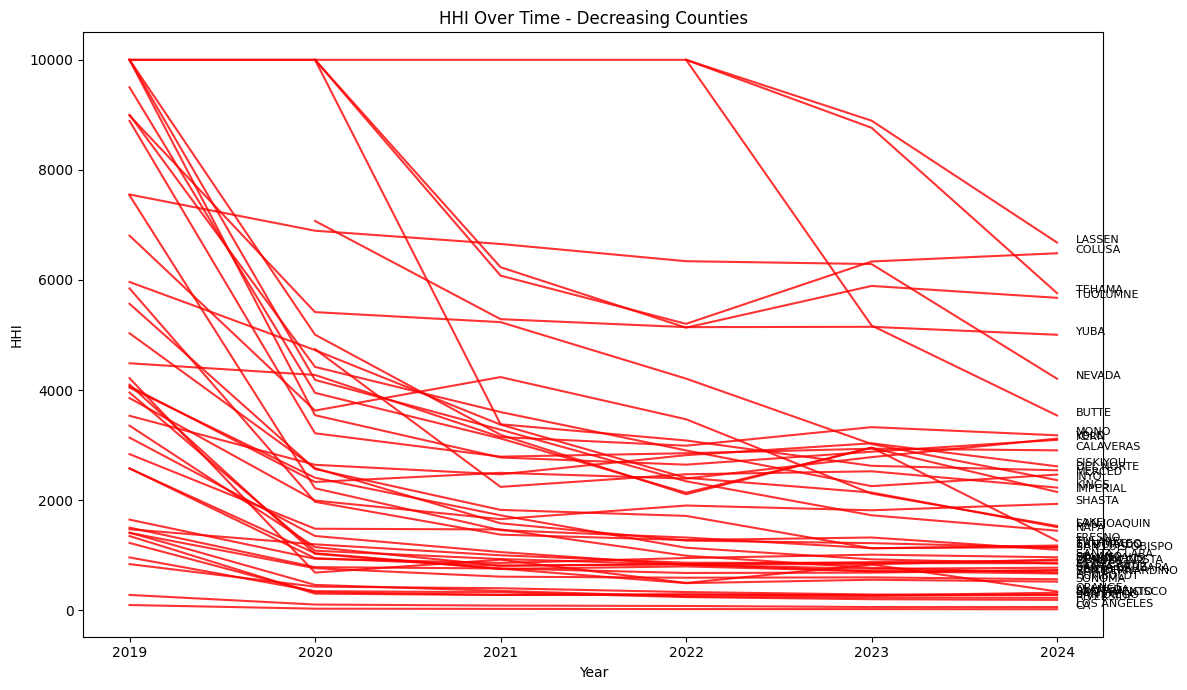

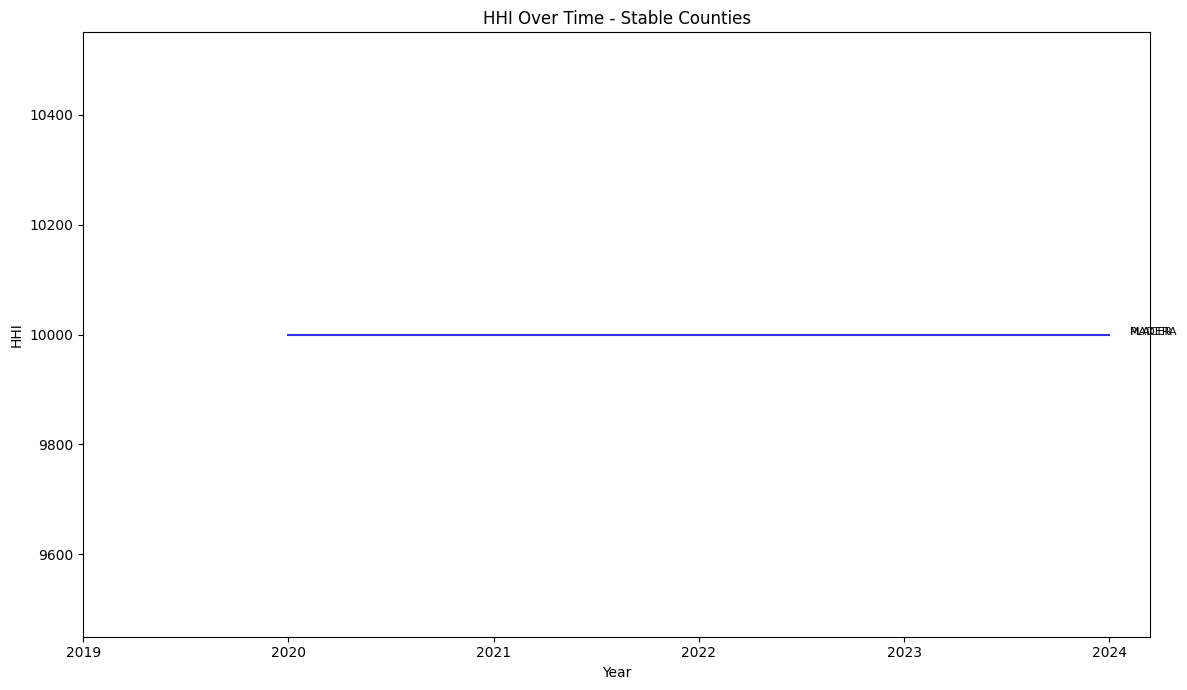

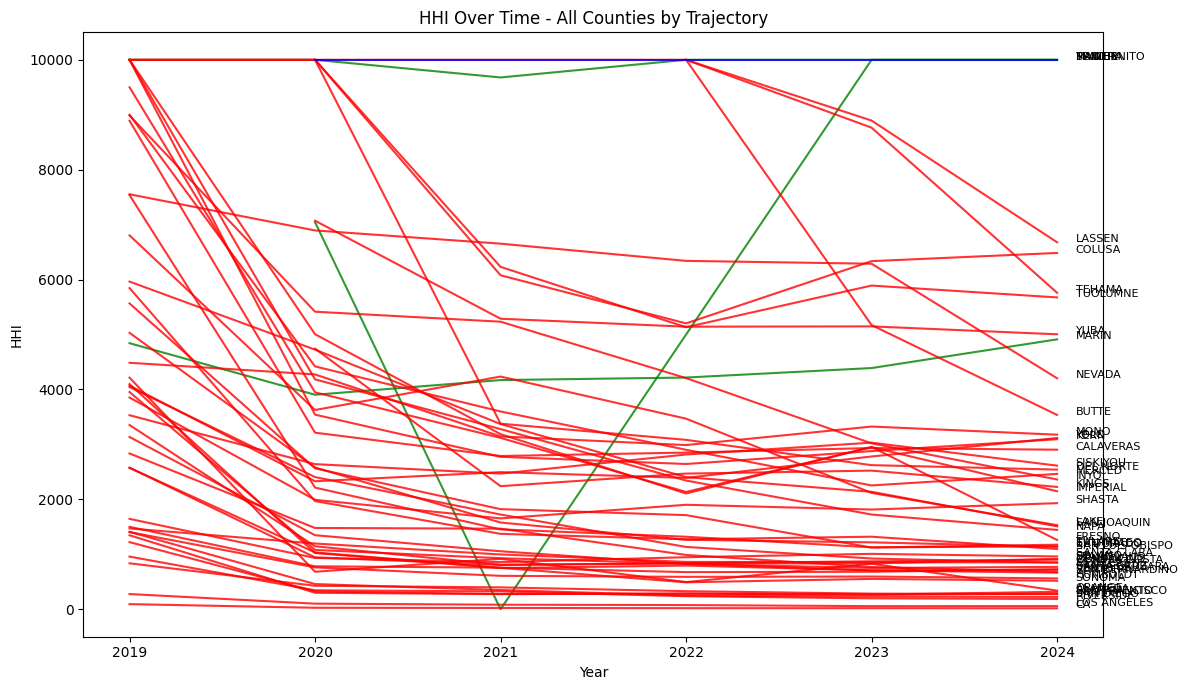

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plot_df = merged.copy()
plot_df = plot_df[plot_df["year"] >= 2019]

counties = plot_df["retailercounty"].unique()

county_groups = {"increasing": [], "decreasing": [], "stable": []}
slopes = {}

for county in counties:
    county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
    
    X = county_data["year"].values
    y = county_data["mkt_share2"].values
    
    slope, intercept = np.polyfit(X, y, 1)
    slopes[county] = slope
    
    if slope > 5:
        county_groups["increasing"].append(county)
    elif slope < -5:
        county_groups["decreasing"].append(county)
    else:
        county_groups["stable"].append(county)

def plot_group(counties, color, title):
    fig, ax = plt.subplots(figsize=(12, 7))
    for county in counties:
        county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
        ax.plot(county_data["year"], county_data["mkt_share2"], label=county, color=color, alpha=0.8)
        ax.text(county_data["year"].iloc[-1] + 0.1,
                county_data["mkt_share2"].iloc[-1],
                county, fontsize=8)
    
    ax.set_xlabel("Year")
    ax.set_ylabel("HHI")
    ax.set_title(title)
    ax.set_xticks(range(2019, 2025))
    ax.set_xticklabels(range(2019, 2025))
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

plot_group(county_groups["increasing"], "green", "HHI Over Time - Increasing Counties")
plot_group(county_groups["decreasing"], "red", "HHI Over Time - Decreasing Counties")
plot_group(county_groups["stable"], "blue", "HHI Over Time - Stable Counties")

fig, ax = plt.subplots(figsize=(12, 7))
colors = {"increasing": "green", "decreasing": "red", "stable": "blue"}

for group, counties in county_groups.items():
    for county in counties:
        county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
        ax.plot(county_data["year"], county_data["mkt_share2"], 
                label=f"{county} ({group})", 
                color=colors[group], alpha=0.8)
        ax.text(county_data["year"].iloc[-1] + 0.1,
                county_data["mkt_share2"].iloc[-1],
                county, fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("HHI")
ax.set_title("HHI Over Time - All Counties by Trajectory")
ax.set_xticks(range(2019, 2025))
ax.set_xticklabels(range(2019, 2025))
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()


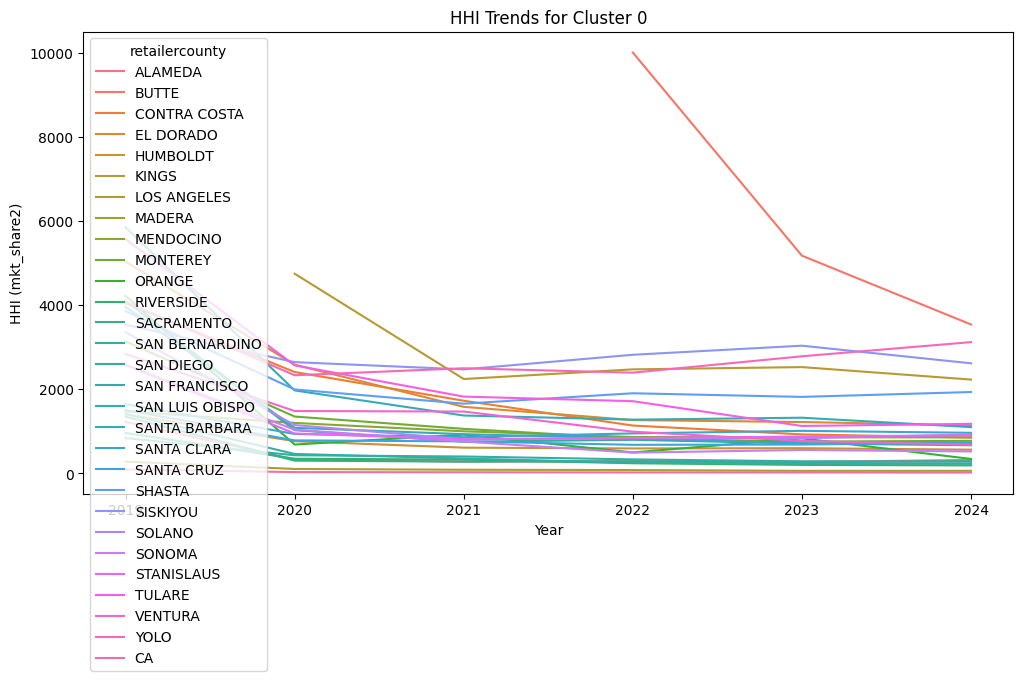

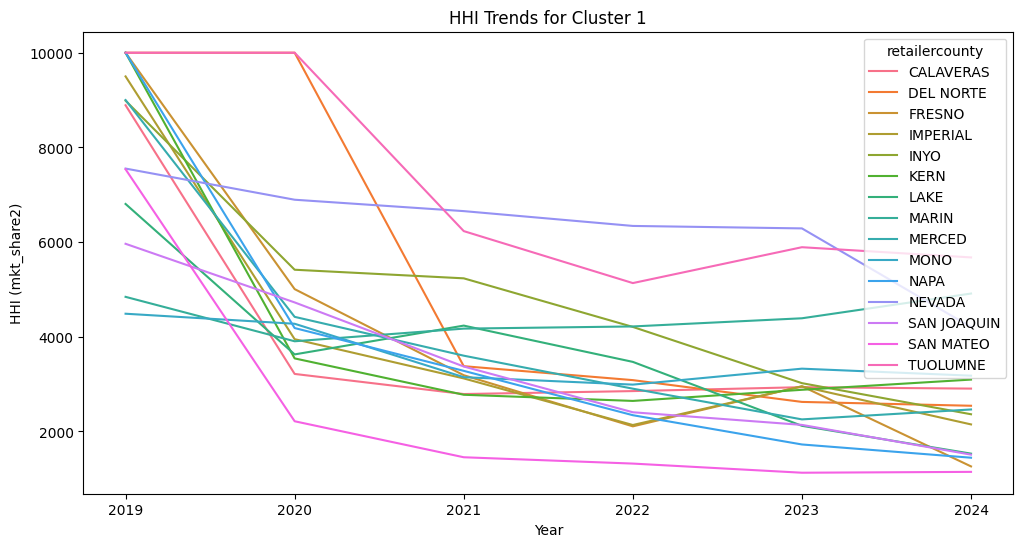

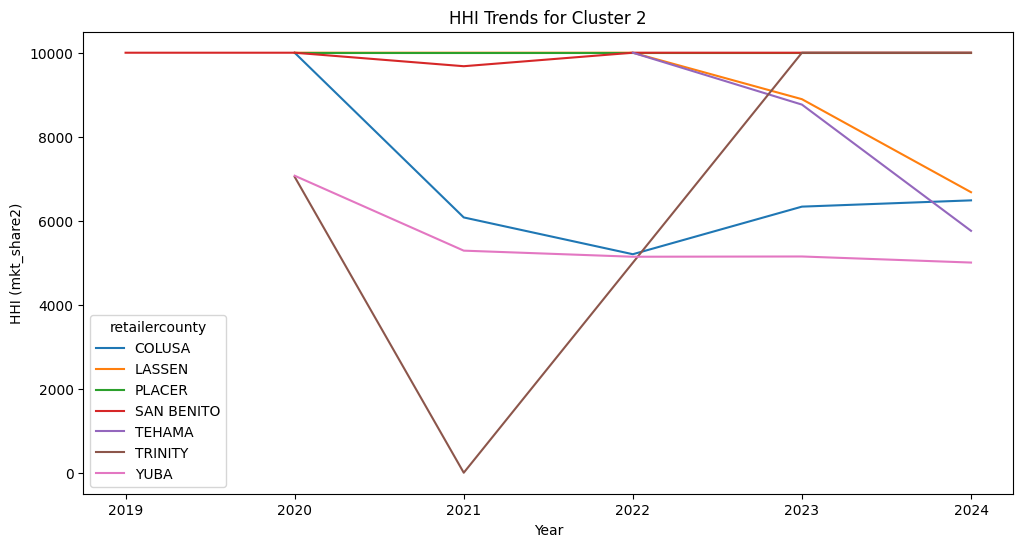

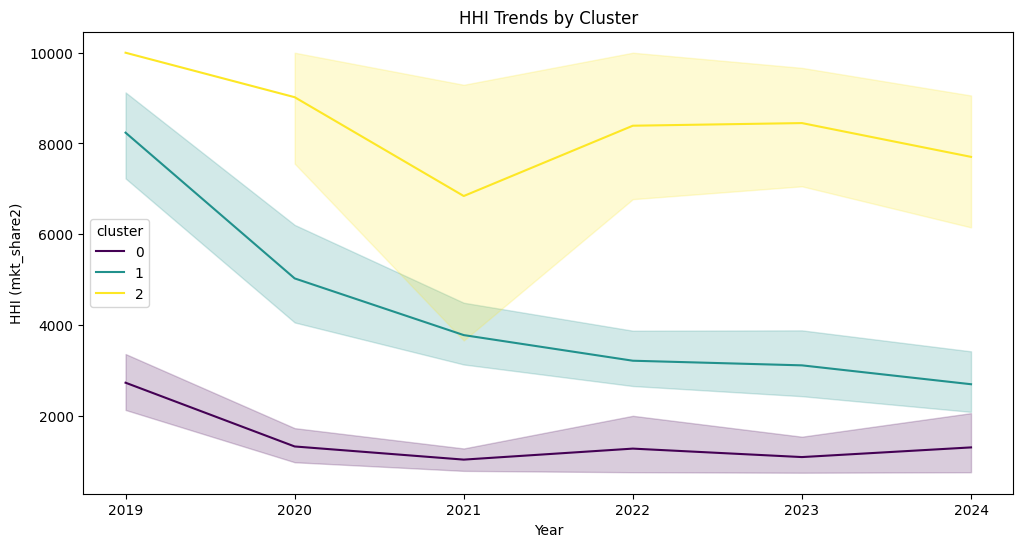

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_clusters = df_filtered['cluster'].unique()

for cluster_label in unique_clusters:
    df_cluster = df_filtered[df_filtered['cluster'] == cluster_label]
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_cluster, x='year', y='mkt_share2', hue='retailercounty')
    plt.title(f'HHI Trends for Cluster {cluster_label}')
    plt.xlabel('Year')
    plt.ylabel('HHI (mkt_share2)')
    plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtered, x='year', y='mkt_share2', hue='cluster', palette='viridis')
plt.title('HHI Trends by Cluster')
plt.xlabel('Year')
plt.ylabel('HHI (mkt_share2)')
plt.show()

In [26]:
import plotly.express as px
import plotly.graph_objects as go

unique_clusters = df_filtered['cluster'].unique()

for cluster_label in unique_clusters:
    df_cluster = df_filtered[df_filtered['cluster'] == cluster_label]

    fig = px.line(
        df_cluster,
        x="year",
        y="mkt_share2",
        color="retailercounty",
        markers=True,
        title=f"HHI Trends for Cluster {cluster_label}",
        labels={"mkt_share2": "HHI (mkt_share2)", "year": "Year"},
    )

    fig.update_layout(
        template="plotly_white",
        width=1300,
        height=750,
        legend=dict(orientation="h", y=-0.25),
        margin=dict(l=50, r=50, t=80, b=80),
    )

    fig.show()

    fig.write_html(f"cluster_{cluster_label}_trends.html")



In [27]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

plot_df = merged.copy()
plot_df = plot_df[plot_df["year"] >= 2019]

counties = plot_df["retailercounty"].unique()

county_groups = {"increasing": [], "decreasing": [], "stable": []}
slopes = {}

for county in counties:
    county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
    
    X = county_data["year"].values.reshape(-1, 1)
    y = county_data["mkt_share2"].values
    
    if len(X) > 1: 
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]
    else:
        slope = 0
    
    slopes[county] = slope
    
    if slope > 5:
        county_groups["increasing"].append(county)
    elif slope < -5:
        county_groups["decreasing"].append(county)
    else:
        county_groups["stable"].append(county)

def plot_group(counties, color, title):
    fig = go.Figure()
    for county in counties:
        county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
        fig.add_trace(go.Scatter(
            x=county_data["year"],
            y=county_data["mkt_share2"],
            mode="lines+markers",
            name=county,
            line=dict(color=color, width=2),
            hovertemplate="<b>%{text}</b><br>Year: %{x}<br>HHI: %{y}<extra></extra>",
            text=[county] * len(county_data)
        ))
    fig.update_layout(
        title=title,
        xaxis_title="Year",
        yaxis_title="HHI",
        template="plotly_white",
        width=1300,
        height=750,
        legend=dict(orientation="h", y=-0.25),
        margin=dict(l=50, r=50, t=80, b=80)
    )
    return fig

fig_increasing = plot_group(county_groups["increasing"], "green", "HHI Over Time - Increasing Counties")
fig_decreasing = plot_group(county_groups["decreasing"], "red", "HHI Over Time - Decreasing Counties")
fig_stable = plot_group(county_groups["stable"], "blue", "HHI Over Time - Stable Counties")

fig_combined = go.Figure()
colors = {"increasing": "green", "decreasing": "red", "stable": "blue"}

for group, counties in county_groups.items():
    for county in counties:
        county_data = plot_df[plot_df["retailercounty"] == county].sort_values("year")
        fig_combined.add_trace(go.Scatter(
            x=county_data["year"],
            y=county_data["mkt_share2"],
            mode="lines+markers",
            name=f"{county} ({group})",
            line=dict(color=colors[group], width=2),
            hovertemplate="<b>%{text}</b><br>Year: %{x}<br>HHI: %{y}<extra></extra>",
            text=[county] * len(county_data)
        ))

fig_combined.update_layout(
    title="HHI Over Time - All Counties by Trajectory",
    xaxis_title="Year",
    yaxis_title="HHI",
    template="plotly_white",
    width=1500,
    height=800,
    legend=dict(orientation="h", y=-0.25),
    margin=dict(l=50, r=50, t=80, b=80)
)

fig_increasing.write_html("increasing_counties.html")
fig_decreasing.write_html("decreasing_counties.html")
fig_stable.write_html("stable_counties.html")
fig_combined.write_html("all_counties.html")

fig_increasing.show()
fig_decreasing.show()
fig_stable.show()
fig_combined.show()


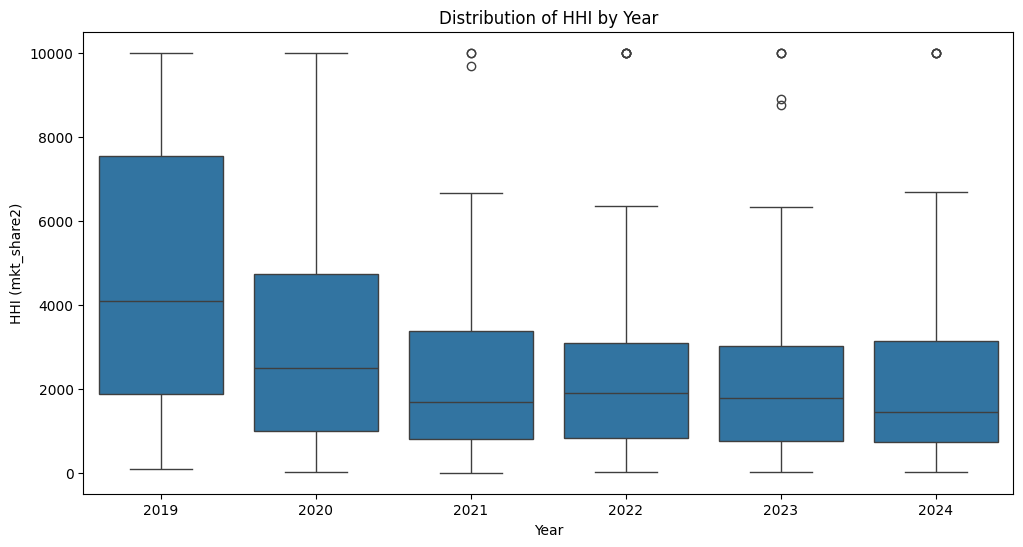

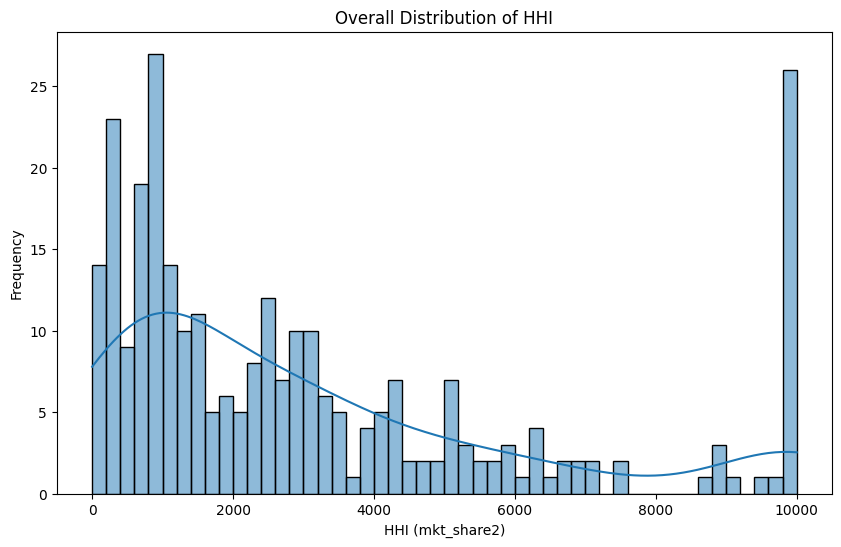

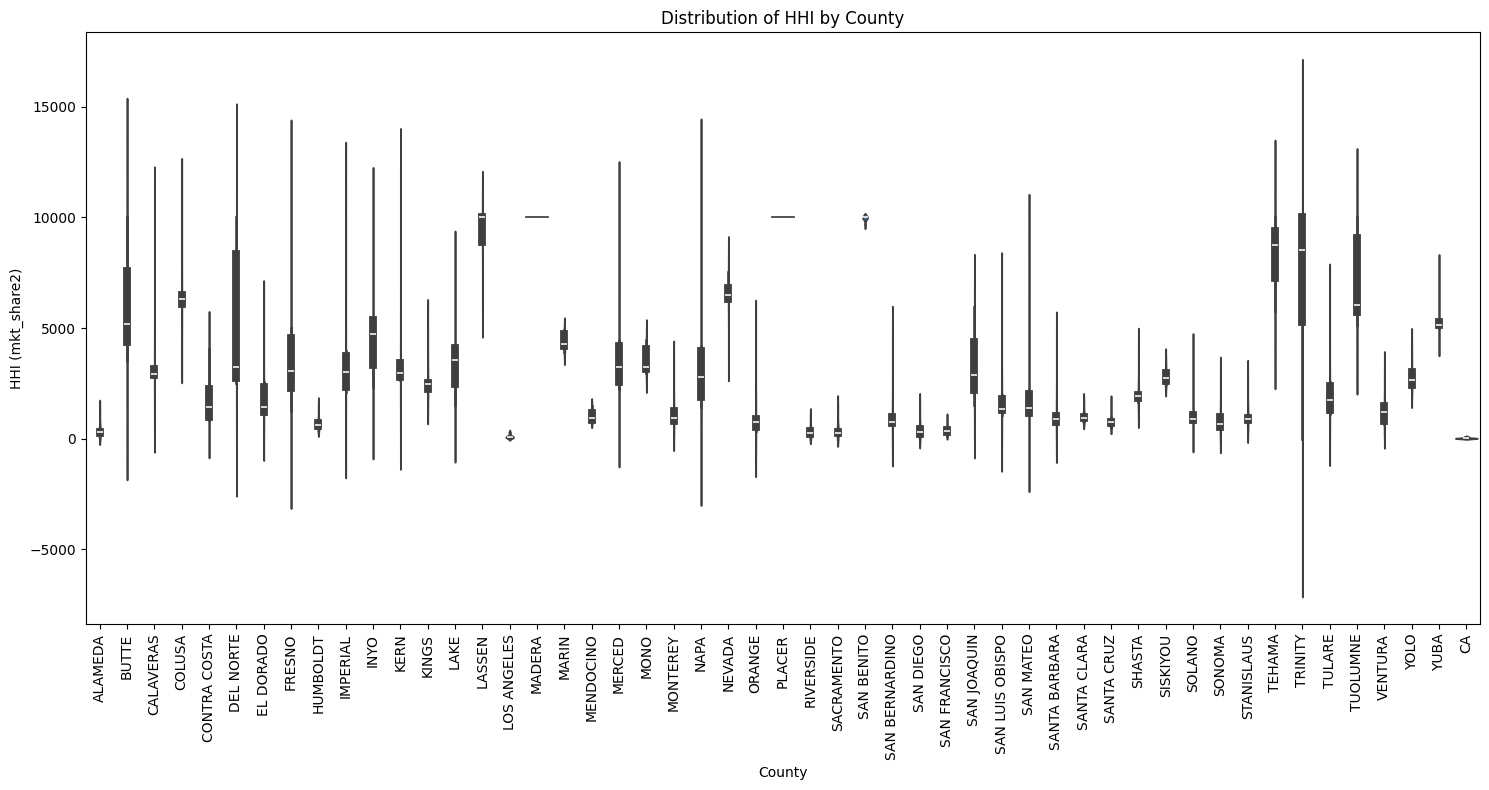

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x='year', y='mkt_share2')
plt.title('Distribution of HHI by Year')
plt.xlabel('Year')
plt.ylabel('HHI (mkt_share2)')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x='mkt_share2', bins=50, kde=True)
plt.title('Overall Distribution of HHI')
plt.xlabel('HHI (mkt_share2)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(15, 8))
sns.violinplot(data=df_filtered, x='retailercounty', y='mkt_share2')
plt.title('Distribution of HHI by County')
plt.xlabel('County')
plt.ylabel('HHI (mkt_share2)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

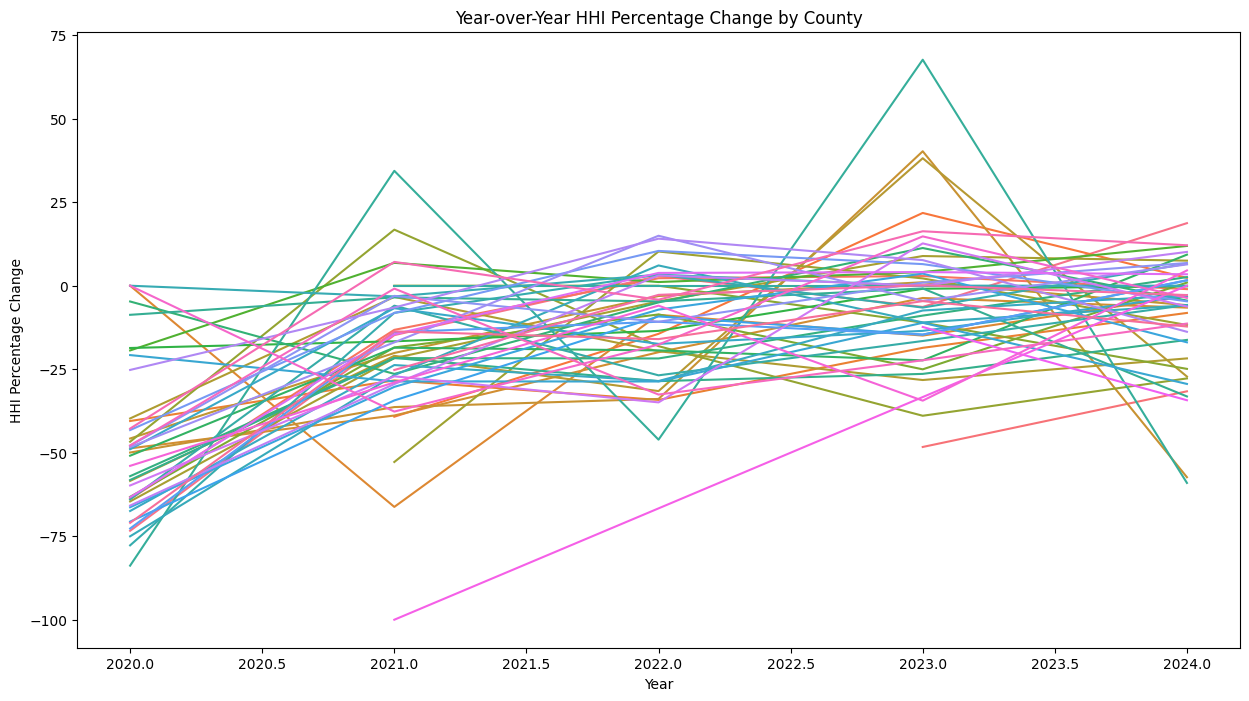

In [29]:
df_filtered['hhi_change'] = df_filtered.groupby('retailercounty')['mkt_share2'].pct_change() * 100

plt.figure(figsize=(15, 8))
sns.lineplot(data=df_filtered, x='year', y='hhi_change', hue='retailercounty')
plt.title('Year-over-Year HHI Percentage Change by County')
plt.xlabel('Year')
plt.ylabel('HHI Percentage Change')
plt.legend().remove()
plt.show()

In [31]:
import plotly.express as px

df_filtered['hhi_change'] = (
    df_filtered.groupby('retailercounty')['mkt_share2'].pct_change() * 100
)

fig = px.line(
    df_filtered,
    x="year",
    y="hhi_change",
    color="retailercounty",
    markers=True,
    title="Year-over-Year HHI Percentage Change by County",
    labels={
        "hhi_change": "HHI % Change",
        "year": "Year",
        "retailercounty": "County"
    }
)

fig.update_layout(
    template="plotly_white",
    width=1500,
    height=800,
    legend=dict(orientation="h", y=-0.25),
    margin=dict(l=50, r=50, t=80, b=80)
)

fig.update_traces(
    hovertemplate="<b>%{text}</b><br>Year: %{x}<br>HHI % Change: %{y:.2f}%<extra></extra>",
    text=df_filtered["retailercounty"]
)

fig.show()

fig.write_html("hhi_yoy_change_by_county.html")


In [30]:
mean_hhi_change = df_filtered.groupby('retailercounty')['hhi_change'].mean().dropna()

top_decreases = mean_hhi_change.sort_values(ascending=True).head(10)
top_increases = mean_hhi_change.sort_values(ascending=False).head(10)

print("Top 10 Counties with Largest Average HHI Decreases:")
display(top_decreases)

print("\nTop 10 Counties with Largest Average HHI Increases:")
display(top_increases)

Top 10 Counties with Largest Average HHI Decreases:


retailercounty
BUTTE          -39.949286
NAPA           -30.198136
FRESNO         -27.453490
SAN DIEGO      -25.991888
CONTRA COSTA   -25.962396
SAN MATEO      -25.441282
RIVERSIDE      -23.820642
TULARE         -23.742305
SAN JOAQUIN    -23.722155
EL DORADO      -23.541125
Name: hhi_change, dtype: float64


Top 10 Counties with Largest Average HHI Increases:


retailercounty
TRINITY             inf
MARIN          0.912721
SAN BENITO     0.021326
PLACER         0.000000
YOLO          -2.289594
SISKIYOU      -4.759972
MONO          -5.860305
COLUSA        -7.372886
YUBA          -7.665520
SANTA CLARA   -7.836840
Name: hhi_change, dtype: float64

,mkt_share2,totalsales,county_sales
mkt_share2,1.000000,-0.240593,-0.251236
totalsales,-0.240593,1.000000,0.913829
county_sales,-0.251236,0.913829,1.000000


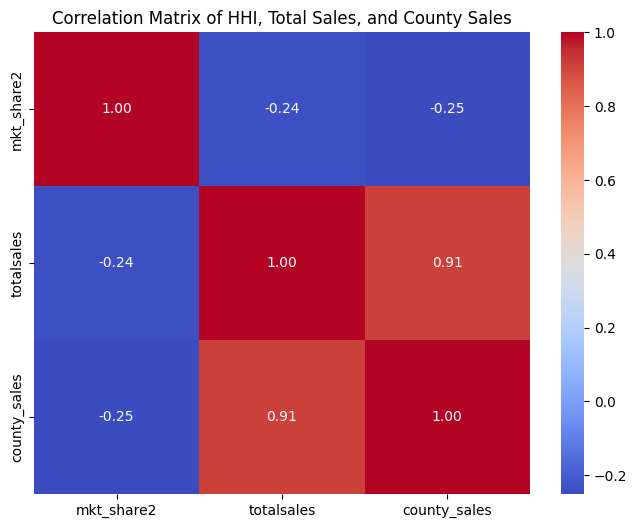

In [32]:
correlation_matrix = df_filtered[['mkt_share2', 'totalsales', 'county_sales']].corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of HHI, Total Sales, and County Sales')
plt.show()